In [1]:
try:
    import ydf
except:
    !uv pip install ydf
    import ydf

print(f"ydf version: {ydf.__version__}")

ydf version: 0.15.0


In [2]:
import os
import torch
import numpy as np
import pandas as pd

from colorama import Fore, Style
import matplotlib.pyplot as plt
import seaborn as sns

## -- Machine Learning --
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import QuantileTransformer, OrdinalEncoder, LabelEncoder, KBinsDiscretizer, TargetEncoder

import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", 500)

# 1. LOAD DATA

In [3]:
TRAIN_PATH = '/kaggle/input/competitions/playground-series-s6e9/train.csv'
TEST_PATH  = '/kaggle/input/competitions/playground-series-s6e9/test.csv'
SUB_PATH   = '/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv'
ORIG_PATH  = '/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/EV_Adoption_and_Range_Anxiety_Dataset.csv'

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
orig  = pd.read_csv(ORIG_PATH)
submission = pd.read_csv(SUB_PATH)

train

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,668660,30,71090.0,27.4,2,5,6,5.0,Male,Urban,Sedan,No,Yes,Medium,No
668661,668661,32,129990.0,5.0,2,5,4,1.0,Female,Suburban,SUV,Yes,Yes,Low,No
668662,668662,64,121791.0,24.2,1,5,6,1.0,Female,Suburban,Hatchback,Yes,Yes,Low,No
668663,668663,51,115923.0,43.7,2,0,0,1.0,Female,Rural,SUV,Yes,Yes,Low,No


# 2.  FEATURE ENGINEERING

In [4]:
TARGET = 'Will_Buy_EV'
train[TARGET] = train[TARGET].map({'Yes': 1, 'No': 0})
orig[TARGET] = orig[TARGET].map({'Yes': 1, 'No': 0})

train['is_train'] = 1
test['is_train'] = 0
test[TARGET] = np.nan
combined = pd.concat([train, test], ignore_index=True)
combined.drop(columns=['Number_of_Cars_Owned'], inplace=True, errors='ignore')

cat_cols = combined.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = [c for c in combined.columns if c not in cat_cols + ['id', 'is_train', TARGET]]
        
# Extract digits from the 10^-4 place up to the 10^3 place
digit_features = []
for c in num_cols:
    scaled = np.rint(combined[c] * 10**4).astype("int64")
    for k in range(-4, 4):
        col_name = f"{c}_digit{k}"
        combined[col_name] = (scaled // 10**(k + 4) % 10).astype('int8')
        # combined[col_name] = (combined[c].fillna(0) // (10**k) % 10).astype('int8')
        digit_features.append(col_name)

# Add the new digit features so they get processed by your frequency/target encoders
num_cols.extend(digit_features)

# Map Original Dataset Target Means
orig_global_mean = orig[TARGET].mean()
for col in cat_cols + num_cols:
    if col in orig.columns:
        real_world_stats = orig.groupby(col, observed=False)[TARGET].mean()
        combined[f"{col}_org_mean"] = combined[col].map(real_world_stats).fillna(orig_global_mean).astype(float)

# Convert Numerics to String Categories
num_to_cat_cols = []
for col in num_cols:
    cat_name = f"{col}_cat"
    combined[cat_name] = combined[col].fillna('NaN').astype(str)
    num_to_cat_cols.append(cat_name)

# Global Frequency Encoding
all_cats = cat_cols + num_to_cat_cols
for col in all_cats:
    freq_mapping = combined[col].value_counts(normalize=True).to_dict()
    combined[f"{col}_fe"] = combined[col].map(freq_mapping).astype(float).fillna(0.0)

# The Mode Collapse Spike
# combined['is_30k_spike'] = (combined['Annual_Income_USD'] == 30000.0).astype('int8')  # Pruned! the XGBoost model do need it
# The Millionaire Cliff (100% buy rate region)
# combined['is_millionaire_cliff'] = (combined['Annual_Income_USD'] >= 170537.0).astype('int8')  # Pruned! the XGBoost model do need it
# The Dead Zone (0% buy rate region)
# combined['is_dead_zone'] = ((combined['Annual_Income_USD'] >= 38000.0) & (combined['Annual_Income_USD'] <= 42000.0)).astype('int8')  # Pruned! the XGBoost model do need it
# Environmental Concern Extremes
combined['is_env_hater'] = (combined['Environmental_Concern_Level'] == 1).astype('int8')

# Markus's "Smooth Keys" (Binned Numerics)
combined['income_exact_int'] = np.floor(combined['Annual_Income_USD']).astype(str)
combined['income100_floor']  = np.floor(combined['Annual_Income_USD'] / 100.0).astype(str)
combined['income1000_floor'] = np.floor(combined['Annual_Income_USD'] / 1000.0).astype(str)
combined['commute_integer']  = np.floor(combined['Daily_Commute_km']).astype(str)
# Adding these 4 new string columns to all_cats so they get Frequency and Target Encoded
all_cats.extend(['income_exact_int', 'income100_floor', 'income1000_floor', 'commute_integer'])

train = combined[combined['is_train'] == 1].drop(columns=['is_train'])
test = combined[combined['is_train'] == 0].drop(columns=['is_train', TARGET])

#  FEATURE DROPPING
# Identify numeric columns to evaluate for correlatio (ignore strings/objects because .corr() will fail on them)
eval_cols = [c for c in train.columns if c not in ['id', TARGET] and pd.api.types.is_numeric_dtype(train[c])]

# Find perfectly correlated features (1.0 correlation)
corr_matrix = train[eval_cols].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] == 1.0)]

# Find constant features (only 1 unique value) in train or test
to_drop_const = [c for c in train.columns if train[c].nunique() == 1] + \
                [c for c in test.columns if test[c].nunique() == 1]

# Combine all bad features into a set to drop
DROP = set(to_drop_corr).union(set(to_drop_const))
DROP = [c for c in DROP if c not in ['id', TARGET]] 

if len(DROP) > 0:
    print(f"   -> Dropping {len(DROP)} redundant/constant features: {DROP}")
    train.drop(columns=DROP, inplace=True, errors='ignore')
    test.drop(columns=DROP, inplace=True, errors='ignore')

FEATURES = [c for c in test.columns if c != 'id']
TARGET_ENCODE_COLS = [c for c in all_cats if c not in DROP] 

# cat_dims  = []
full_data = pd.concat([train, test])
for c in TARGET_ENCODE_COLS:
    le = LabelEncoder().fit(full_data[c].astype(str))
    train[c] = le.transform(train[c].astype(str)).astype(str)
    test[c]  = le.transform(test[c].astype(str)).astype(str)
    # cat_dims.append(len(le.classes_))

print(f"✅ Total Features: {len(FEATURES)}")
print(f"✅ Columns to Target Encode: {len(TARGET_ENCODE_COLS)}")

train

   -> Dropping 104 redundant/constant features: ['Environmental_Concern_Level_digit2', 'Charging_Stations_Near_Work_digit2_cat_fe', 'Daily_Commute_km_digit-2_cat', 'Environmental_Concern_Level_digit3', 'Age_digit3_cat_fe', 'Charging_Stations_Near_Work_digit-2', 'Charging_Stations_Near_Work_digit-2_cat', 'Charging_Stations_Near_Work_digit3', 'Annual_Income_USD_digit-1_cat', 'Daily_Commute_km_digit-3_cat_fe', 'Charging_Stations_Near_Home_digit-2_cat_fe', 'Environmental_Concern_Level_digit0_cat_fe', 'Annual_Income_USD_digit-2_cat', 'Daily_Commute_km_digit3_cat', 'Daily_Commute_km_digit3', 'Charging_Stations_Near_Work_digit-3_cat_fe', 'Environmental_Concern_Level_digit-1_cat_fe', 'Annual_Income_USD_digit-2', 'Age_digit-4_cat_fe', 'Charging_Stations_Near_Home_digit-2', 'Environmental_Concern_Level_digit-3_cat', 'Daily_Commute_km_digit3_cat_fe', 'Age_digit-3', 'Environmental_Concern_Level_digit-1_cat', 'Charging_Stations_Near_Work_digit-3', 'Age_digit-1', 'Daily_Commute_km_digit2', 'Environm

,id,Age,Annual_Income_USD,Daily_Commute_km,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV,Age_digit0,Age_digit1,Annual_Income_USD_digit0,Annual_Income_USD_digit1,Annual_Income_USD_digit2,Annual_Income_USD_digit3,Daily_Commute_km_digit-1,Daily_Commute_km_digit0,Daily_Commute_km_digit1,Charging_Stations_Near_Home_digit0,Charging_Stations_Near_Home_digit1,Charging_Stations_Near_Work_digit0,Charging_Stations_Near_Work_digit1,Gender_org_mean,City_Type_org_mean,Current_Car_Type_org_mean,Home_Charging_Possible_org_mean,Subsidy_Available_org_mean,Range_Anxiety_Level_org_mean,Age_org_mean,Annual_Income_USD_org_mean,Daily_Commute_km_org_mean,Charging_Stations_Near_Home_org_mean,Charging_Stations_Near_Work_org_mean,Environmental_Concern_Level_org_mean,Age_cat,Annual_Income_USD_cat,Daily_Commute_km_cat,Charging_Stations_Near_Home_cat,Charging_Stations_Near_Work_cat,Environmental_Concern_Level_cat,Age_digit0_cat,Age_digit1_cat,Annual_Income_USD_digit0_cat,Annual_Income_USD_digit1_cat,Annual_Income_USD_digit2_cat,Annual_Income_USD_digit3_cat,Daily_Commute_km_digit-1_cat,Daily_Commute_km_digit0_cat,Daily_Commute_km_digit1_cat,Charging_Stations_Near_Home_digit0_cat,Charging_Stations_Near_Home_digit1_cat,Charging_Stations_Near_Work_digit0_cat,Charging_Stations_Near_Work_digit1_cat,Environmental_Concern_Level_digit0_cat,Gender_fe,City_Type_fe,Current_Car_Type_fe,Home_Charging_Possible_fe,Subsidy_Available_fe,Range_Anxiety_Level_fe,Age_cat_fe,Annual_Income_USD_cat_fe,Daily_Commute_km_cat_fe,Charging_Stations_Near_Home_cat_fe,Charging_Stations_Near_Work_cat_fe,Environmental_Concern_Level_cat_fe,Age_digit0_cat_fe,Age_digit1_cat_fe,Annual_Income_USD_digit0_cat_fe,Annual_Income_USD_digit1_cat_fe,Annual_Income_USD_digit2_cat_fe,Annual_Income_USD_digit3_cat_fe,Daily_Commute_km_digit-1_cat_fe,Daily_Commute_km_digit0_cat_fe,Daily_Commute_km_digit1_cat_fe,Charging_Stations_Near_Home_digit0_cat_fe,Charging_Stations_Near_Home_digit1_cat_fe,Charging_Stations_Near_Work_digit0_cat_fe,Charging_Stations_Near_Work_digit1_cat_fe,is_env_hater,income_exact_int,income100_floor,income1000_floor,commute_integer
0,0,66,92887.0,23.4,3,7,1.0,1,1,2,1,0,1,0.0,6,6,7,8,8,2,4,3,2,3,0,7,0,0.170929,0.176817,0.172250,0.200714,0.025301,0.198676,0.200913,0.000000,0.181818,0.154994,0.166913,0.021361,41,13255,136,8,17,0,6,4,7,8,8,2,4,3,2,3,0,7,0,0,0.550232,0.382160,0.453965,0.69214,0.371583,0.903671,0.022189,0.000156,0.001025,0.088105,0.067977,0.220470,0.119046,0.218299,0.089344,0.098165,0.136997,0.114493,0.089187,0.068507,0.155343,0.119869,0.839831,0.095176,0.742066,1,13255,1083,144,14
1,1,38,30000.0,5.0,2,2,4.0,1,0,1,1,0,1,0.0,8,3,0,0,0,0,0,5,0,2,0,2,0,0.170929,0.189840,0.181010,0.200714,0.025301,0.198676,0.175355,0.066427,0.191517,0.187404,0.188034,0.252891,13,4880,402,7,12,3,8,1,0,0,0,0,0,5,0,2,0,2,0,3,0.550232,0.185583,0.368738,0.69214,0.371583,0.903671,0.020044,0.091999,0.215599,0.151632,0.074310,0.195549,0.107725,0.218350,0.199227,0.149168,0.146475,0.158213,0.292327,0.290030,0.218171,0.183997,0.839831,0.100067,0.742066,0,4880,597,87,41
2,2,26,94389.0,36.8,8,15,5.0,0,2,2,0,1,1,1.0,6,2,9,8,3,4,8,6,3,8,0,5,1,0.180302,0.169197,0.172250,0.133698,0.274467,0.198676,0.200000,1.000000,0.285714,0.195710,0.166667,0.414046,1,13594,270,13,7,4,6,0,9,8,3,4,8,6,3,8,0,5,1,4,0.441876,0.432257,0.453965,0.30786,0.628417,0.903671,0.022353,0.000063,0.002892,0.031121,0.024436,0.191398,0.119046,0.108970,0.090048,0.098165,0.073144,0.109598,0.076601,0.083534,0.184213,0.031121,0.839831,0.094157,0.257934,0,13594,1098,146,27
3,3,66,73580.0,23.7,6,9,3.0,1,1,0,1,0,1,0.0,6,6,0,8,5,3,7,3,2,6,0,9,0,0.170929,0.176817,0.174655,0.200714,0.025301,0.198676,0.200913,1.000000,0.300000,0.159174,0.178470,0.144535,41,8959,139,11,19,2,6,4,0,8,5,3,7,3,2,6,0,9,0,2,0.550232,0.382160,0.118863,0.69214,0.371583,0.903671,0.022189,0.000263,0.000950,0.083082,0.074363,0.190380,0.119046,0.

In [5]:
# ==========================================
# MANUAL FEATURE PRUNING (Calculated via Gain Thresholding)
# ==========================================
print("✂️ Feature for dynamic pruning (Dropping 88 low-gain features)...")

features_to_drop = [
    'Age', 'Daily_Commute_km_digit-3_cat_TE_100', 'Charging_Stations_Near_Home_digit0',
    'Daily_Commute_km_digit1_cat_TE_100', 'Annual_Income_USD_digit1', 'Charging_Stations_Near_Work_digit1_cat_TE_auto',
    'Daily_Commute_km_digit1_cat_TE_auto', 'Daily_Commute_km_digit0_cat_TE_10', 'Gender_org_mean',
    'Daily_Commute_km_digit-4_cat_TE_100', 'Daily_Commute_km_digit0_cat_TE_auto', 'Daily_Commute_km_digit-4_cat_TE_auto',
    'Daily_Commute_km_cat_fe', 'Annual_Income_USD_digit1_cat_fe', 'Charging_Stations_Near_Work_digit0_cat_TE_100',
    'Annual_Income_USD_digit2_cat_TE_100', 'Annual_Income_USD_digit0', 'Charging_Stations_Near_Home_digit-3_cat_TE_auto',
    'Gender_TE_100', 'Current_Car_Type_TE_10', 'Age_digit1_cat_fe', 'Charging_Stations_Near_Work_digit1_cat_TE_100',
    'Annual_Income_USD_digit0_cat_TE_10', 'Daily_Commute_km_digit-3_cat_TE_10', 'Charging_Stations_Near_Work_digit0_cat_TE_10',
    'Gender_TE_auto', 'Daily_Commute_km_digit0_cat_TE_100', 'Charging_Stations_Near_Home_digit-4_cat_TE_auto',
    'Daily_Commute_km_digit-1_cat_TE_10', 'Charging_Stations_Near_Work_digit0_cat_TE_auto', 'Daily_Commute_km_digit-1',
    'Charging_Stations_Near_Work_digit0', 'Annual_Income_USD_digit0_cat_TE_auto', 'Daily_Commute_km_digit-4_cat_TE_10',
    'Charging_Stations_Near_Work_digit-3_cat_TE_auto', 'Charging_Stations_Near_Work_org_mean', 'Age_digit0_cat_TE_auto',
    'Age_digit0_cat_fe', 'Annual_Income_USD_digit0_cat_fe', 'Charging_Stations_Near_Home_digit-4_cat_TE_100',
    'Daily_Commute_km_digit-3_cat_TE_auto', 'Age_digit0', 'Annual_Income_USD_digit2_cat_TE_auto',
    'Annual_Income_USD_digit0_cat_TE_100', 'Daily_Commute_km_org_mean', 'Age_digit0_cat_TE_10',
    'Current_Car_Type_TE_auto', 'Current_Car_Type_TE_100', 'Age_digit1_cat_TE_auto', 'Charging_Stations_Near_Home_digit-4',
    'Annual_Income_USD_digit2_cat_TE_10', 'Daily_Commute_km_digit-1_cat_TE_100', 'Age_cat_fe',
    'Daily_Commute_km_digit0_cat_fe', 'Daily_Commute_km_digit-1_cat_fe', 'Daily_Commute_km_digit-1_cat_TE_auto',
    'Daily_Commute_km_digit-2_cat_TE_10', 'Age_digit1', 'Age_digit1_cat_TE_100', 'Gender_TE_10', 'Age_digit1_cat_TE_10',
    'Age_digit0_cat_TE_100', 'Daily_Commute_km_digit-3', 'Charging_Stations_Near_Home_digit-3_cat_TE_100', 'Gender_fe',
    'Charging_Stations_Near_Home_digit-3_cat_TE_10', 'Daily_Commute_km_digit-4_cat_fe', 'Daily_Commute_km_digit-4',
    'Daily_Commute_km_digit-3_cat_fe', 'Charging_Stations_Near_Work_digit-3_cat_TE_10', 'Daily_Commute_km_digit-2_cat_TE_100',
    'Charging_Stations_Near_Home_digit-2_cat_TE_auto', 'Charging_Stations_Near_Home_digit-1_cat_TE_auto',
    'Charging_Stations_Near_Work_digit1_cat_fe', 'Charging_Stations_Near_Work_digit-2_cat_TE_100',
    'Charging_Stations_Near_Home_digit-2_cat_TE_100', 'Charging_Stations_Near_Work_digit-3_cat_TE_100', 'is_dead_zone',
    'is_millionaire_cliff', 'is_30k_spike', 'Charging_Stations_Near_Home_digit-1_cat_TE_100',
    'Charging_Stations_Near_Home_digit-1_cat_TE_10', 'Charging_Stations_Near_Home_digit-2_cat_TE_10',
    'Charging_Stations_Near_Work_digit-1_cat_TE_10', 'Charging_Stations_Near_Work_digit-2_cat_TE_auto',
    'Charging_Stations_Near_Work_digit-1_cat_TE_auto', 'Charging_Stations_Near_Work_digit-1_cat_TE_100',
    'Charging_Stations_Near_Work_digit-2_cat_TE_10'
]

✂️ Feature for dynamic pruning (Dropping 88 low-gain features)...


In [6]:
# %%time

# X = train[FEATURES]
# train[TARGET] = train[TARGET].astype(int) 

# ## -- Search HPO space for 'LOCAL' & 'BEST_FIRST_GLOBAL' --

# tuner = ydf.RandomSearchTuner(num_trials=20, automatic_search_space=False)
# # tuner.choice('num_trees', [5000, 2000])
# # tuner.choice('shrinkage', [0.02, 0.05]) 
# # tuner.choice('subsample', [0.9, 1.0])
# tuner.choice('categorical_algorithm', ['CART', 'RANDOM']) #'CART', 'RANDOM', 'ONE_HOT'
# tuner.choice('l2_regularization', [0.0, 0.1, 0.5, 1.0])

# ## -- 'LOCAL' acts like 'depthwise': uses 'max_depth' --
# local_subspace = tuner.choice('growing_strategy', ['LOCAL'])
# local_subspace.choice('max_depth', [4, 6])

# ## -- 'BEST_FIRST_GLOBAL' acts like 'lossguide': uses 'max_num_nodes' --
# global_subspace = tuner.choice('growing_strategy', ['BEST_FIRST_GLOBAL'], merge=True)
# # global_subspace.choice('max_num_nodes', [None, 32, 64, 128])

# # ## -- Enable ydf process numeric features as categories --
# # num_as_cat = []
# # for f in CATS:
# #     num_as_cat.append(ydf.Feature(f, ydf.Semantic.CATEGORICAL))

# ydf_HPO_model = ydf.GradientBoostedTreesLearner(
#     task=ydf.Task.CLASSIFICATION,
#     label=TARGET, 
#     tuner=tuner,
#     num_trees=10_000,
#     # shrinkage=0.1,
#     # class_weights=get_class_weights(train_data[TARGET]), ## 
#     # max_depth=4,
#     # features=num_as_cat,
#     # include_all_columns=True,
#     # l2_regularization=0.15,
#     # categorical_algorithm='RANDOM',
#     # early_stopping_initial_iteration=10,
#     # early_stopping_num_trees_look_ahead=100,
#     random_seed=42, 
#     num_threads=3, 
# ).train(train[FEATURES+[TARGET]], verbose=1)

# ydf_HPO_model.describe()

## HPO SEARCH

In [7]:
# %%time 

# ## -- Search HPO space in 'LOCAL' & 'BEST_FIRST_GLOBAL' -- 
# MODEL_NAME = 'YDFsearch'
# FOLDS = 3

# print(f"\n🚀 Training {MODEL_NAME} with {FOLDS} Folds...")

# X = train[FEATURES]
# y = train[TARGET].astype(int)
# X_test = test[FEATURES]

# skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)
# oof_preds  = np.zeros(len(train))
# test_preds = np.zeros(len(test))

# # feature_importances = pd.DataFrame()
# ydf_models = []

# for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
#     X_train, y_train = X.iloc[train_idx].copy(), y.iloc[train_idx]
#     X_valid, y_valid = X.iloc[valid_idx].copy(), y.iloc[valid_idx]
#     # X_test_fold = X_test.copy()

#     # Triple Sklearn Target Encoders (Auto, Strict 10, and Massive 100)
#     te_auto = TargetEncoder(shuffle=True, cv=5, smooth='auto', random_state=42)
#     te_10   = TargetEncoder(shuffle=True, cv=5, smooth=10.0, random_state=42)
#     te_100  = TargetEncoder(shuffle=True, cv=5, smooth=100.0, random_state=42)

#     X_train_enc_auto = te_auto.fit_transform(X_train[TARGET_ENCODE_COLS], y_train)
#     X_valid_enc_auto = te_auto.transform(X_valid[TARGET_ENCODE_COLS])
#     # X_test_enc_auto  = te_auto.transform(X_test_fold[TARGET_ENCODE_COLS])

#     X_train_enc_10 = te_10.fit_transform(X_train[TARGET_ENCODE_COLS], y_train)
#     X_valid_enc_10 = te_10.transform(X_valid[TARGET_ENCODE_COLS])
#     # X_test_enc_10  = te_10.transform(X_test_fold[TARGET_ENCODE_COLS])

#     X_train_enc_100 = te_100.fit_transform(X_train[TARGET_ENCODE_COLS], y_train)
#     X_valid_enc_100 = te_100.transform(X_valid[TARGET_ENCODE_COLS])
#     # X_test_enc_100  = te_100.transform(X_test_fold[TARGET_ENCODE_COLS])

#     for i, col in enumerate(TARGET_ENCODE_COLS):
#         # Auto smoothing TE
#         X_train[f"{col}_TE_auto"] = X_train_enc_auto[:, i].astype('float32')
#         X_valid[f"{col}_TE_auto"] = X_valid_enc_auto[:, i].astype('float32')
#         # X_test_fold[f"{col}_TE_auto"] = X_test_enc_auto[:, i].astype('float32')
        
#         # Strict (10.0) smoothing TE
#         X_train[f"{col}_TE_10"] = X_train_enc_10[:, i].astype('float32')
#         X_valid[f"{col}_TE_10"] = X_valid_enc_10[:, i].astype('float32')
#         # X_test_fold[f"{col}_TE_10"] = X_test_enc_10[:, i].astype('float32')

#         # Massive (100.0) smoothing TE (Markus's method)
#         X_train[f"{col}_TE_100"] = X_train_enc_100[:, i].astype('float32')
#         X_valid[f"{col}_TE_100"] = X_valid_enc_100[:, i].astype('float32')
#         # X_test_fold[f"{col}_TE_100"] = X_test_enc_100[:, i].astype('float32')
        
#         # Drop the original string column
#         X_train.drop(columns=[col], inplace=True)
#         X_valid.drop(columns=[col], inplace=True)
#         # X_test_fold.drop(columns=[col], inplace=True)
        
#     # APPLY DYNAMIC PRUNING
#     if len(features_to_drop) > 0:
#         # Check X_train.columns because it contains both base features and the new _TE_ features
#         safe_to_drop = [c for c in features_to_drop if c in X_train.columns]
        
#         if len(safe_to_drop) > 0:
#             if fold == 1:
#                 print(f"   -> Successfully pruned {len(safe_to_drop)} features.")
                
#             X_train.drop(columns=safe_to_drop, inplace=True, errors='ignore')
#             X_valid.drop(columns=safe_to_drop, inplace=True, errors='ignore')
#             # X_test_fold.drop(columns=safe_to_drop, inplace=True, errors='ignore')

#     if fold == 1:
#         display(X_train.head())
    
#     tuner = ydf.RandomSearchTuner(num_trials=30, automatic_search_space=False)
#     # tuner.choice('num_trees', [5000, 2000])
#     # tuner.choice('shrinkage', [0.02, 0.05]) 
#     # tuner.choice('subsample', [0.9, 1.0])
#     tuner.choice('categorical_algorithm', ['CART', 'RANDOM']) #'CART', 'RANDOM', 'ONE_HOT'
#     tuner.choice('l2_regularization', [0.0, 0.1, 0.5])
    
#     ## -- 'LOCAL' acts like 'depthwise': uses 'max_depth' --
#     local_subspace = tuner.choice('growing_strategy', ['LOCAL'])
#     local_subspace.choice('max_depth', [4, 5, 6, 8])
    
#     ## -- 'BEST_FIRST_GLOBAL' acts like 'lossguide': uses 'max_num_nodes' --
#     global_subspace = tuner.choice('growing_strategy', ['BEST_FIRST_GLOBAL'], merge=True)
#     # global_subspace.choice('max_num_nodes', [None, 32, 64, 128])
    
#     # ## -- Enable ydf process numeric features as categories --
#     # num_as_cat = []
#     # for f in CATS:
#     #     num_as_cat.append(ydf.Feature(f, ydf.Semantic.CATEGORICAL))

#     ydf_HPO_model = ydf.GradientBoostedTreesLearner(
#         task=ydf.Task.CLASSIFICATION,
#         label=TARGET, 
#         tuner=tuner,
#         num_trees=1000,
#         shrinkage=0.1,
#         # class_weights=get_class_weights(train_data[TARGET]), ## 
#         # max_depth=4,
#         # features=num_as_cat,
#         # include_all_columns=True,
#         # l2_regularization=0.15,
#         # categorical_algorithm='RANDOM',
#         # early_stopping_initial_iteration=10,
#         early_stopping_num_trees_look_ahead=50,
#         random_seed=42, 
#         num_threads=3, 
#     ).train(pd.concat([X_train, y_train], axis=1), verbose=1)
    
#     ydf_models.append(ydf_HPO_model)

In [8]:
# ydf_models[0].describe()

In [9]:
# ydf_models[1].describe()

In [10]:
# ydf_models[2].describe()

# 3. 10 FOLD CV WITH SKLEARN TARGET ENCODING

In [11]:
USE_FULL_TRAIN = True

x_sample, x_sample2 = train_test_split(train, train_size=300_000, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()

train_data.shape

(668665, 89)

In [12]:
%%time

MODEL_NAME = 'YDFlocal89_(3)TE'
FOLDS = 10

print(f"\n🚀 Training {MODEL_NAME} with {FOLDS} Folds...")

X = train_data[FEATURES]
y = train_data[TARGET].astype(int)
X_test = test[FEATURES]

skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)
oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n--- FOLD {fold}/{FOLDS} ---")
    X_train, y_train = X.iloc[train_idx].copy(), y.iloc[train_idx]
    X_valid, y_valid = X.iloc[valid_idx].copy(), y.iloc[valid_idx]
    X_test_fold = X_test.copy()

    # Triple Sklearn Target Encoders (Auto, Strict 10, and Massive 100)
    te_auto = TargetEncoder(shuffle=True, cv=5, smooth='auto', random_state=42)
    te_10   = TargetEncoder(shuffle=True, cv=5, smooth=10.0, random_state=42)
    te_100  = TargetEncoder(shuffle=True, cv=5, smooth=100.0, random_state=42)

    X_train_enc_auto = te_auto.fit_transform(X_train[TARGET_ENCODE_COLS], y_train)
    X_valid_enc_auto = te_auto.transform(X_valid[TARGET_ENCODE_COLS])
    X_test_enc_auto  = te_auto.transform(X_test_fold[TARGET_ENCODE_COLS])

    X_train_enc_10 = te_10.fit_transform(X_train[TARGET_ENCODE_COLS], y_train)
    X_valid_enc_10 = te_10.transform(X_valid[TARGET_ENCODE_COLS])
    X_test_enc_10  = te_10.transform(X_test_fold[TARGET_ENCODE_COLS])

    X_train_enc_100 = te_100.fit_transform(X_train[TARGET_ENCODE_COLS], y_train)
    X_valid_enc_100 = te_100.transform(X_valid[TARGET_ENCODE_COLS])
    X_test_enc_100  = te_100.transform(X_test_fold[TARGET_ENCODE_COLS])

    for i, col in enumerate(TARGET_ENCODE_COLS):
        # Auto smoothing TE
        X_train[f"{col}_TE_auto"] = X_train_enc_auto[:, i].astype('float32')
        X_valid[f"{col}_TE_auto"] = X_valid_enc_auto[:, i].astype('float32')
        X_test_fold[f"{col}_TE_auto"] = X_test_enc_auto[:, i].astype('float32')
        
        # Strict (10.0) smoothing TE
        X_train[f"{col}_TE_10"] = X_train_enc_10[:, i].astype('float32')
        X_valid[f"{col}_TE_10"] = X_valid_enc_10[:, i].astype('float32')
        X_test_fold[f"{col}_TE_10"] = X_test_enc_10[:, i].astype('float32')

        # Massive (100.0) smoothing TE (Markus's method)
        X_train[f"{col}_TE_100"] = X_train_enc_100[:, i].astype('float32')
        X_valid[f"{col}_TE_100"] = X_valid_enc_100[:, i].astype('float32')
        X_test_fold[f"{col}_TE_100"] = X_test_enc_100[:, i].astype('float32')
        
        # Drop the original string column
        X_train.drop(columns=[col], inplace=True)
        X_valid.drop(columns=[col], inplace=True)
        X_test_fold.drop(columns=[col], inplace=True)

    # APPLY DYNAMIC PRUNING
    if len(features_to_drop) > 0:
        # Check X_train.columns because it contains both base features and the new _TE_ features
        safe_to_drop = [c for c in features_to_drop if c in X_train.columns]
        
        if len(safe_to_drop) > 0:
            if fold == 1:
                print(f"   -> Successfully pruned {len(safe_to_drop)} features.")
                
            X_train.drop(columns=safe_to_drop, inplace=True, errors='ignore')
            X_valid.drop(columns=safe_to_drop, inplace=True, errors='ignore')
            X_test_fold.drop(columns=safe_to_drop, inplace=True, errors='ignore')

    print(f"train={X_train.shape}, valid={X_valid.shape}")
    if fold == 1:
        display(X_train.head())

    # -- TUNED YDF MODEL --
    local_params = {
        'task': ydf.Task.CLASSIFICATION,
        'growing_strategy': "LOCAL",
        'num_trees': 1500, # def=300
        'max_depth': 4,
        'shrinkage': 0.05, # def=0.1
        'categorical_algorithm': "RANDOM", # "CART", "RANDOM", 'ONE_HOT'
        # 'sampling_method': 'RANDOM', # 'RANDOM', 'GOSS', 'SELGB'
        # 'split_axis': , # 'AXIS_ALIGNED', 'SPARSE_OBLIQUE', 'MHLD_OBLIQUE'
        # 'subsample': 0.95, # default RANDOM sampling
        # 'goss_alpha': 0.2, # activates GOSS sampling
        # 'l2_regularization': 1.0,
        # 'early_stopping': 'NONE', # 'NONE', 'MIN_LOSS_FINAL', 'LOSS_INCREASE'
        # 'early_stopping_initial_iteration': 10,
        # 'min_examples': 10,
        # 'num_discretized_numerical_bins': 1024,
        'early_stopping_num_trees_look_ahead': 100,
        'random_seed': 42,
    }
    global_params = {
        'task': ydf.Task.CLASSIFICATION,
        'growing_strategy': "BEST_FIRST_GLOBAL",
        'num_trees': 1000,
        # 'max_num_nodes': None,
        'shrinkage': 0.05,
        'categorical_algorithm': 'RANDOM', # 'CART', 'RANDOM', 'ONE_HOT'
        # 'sampling_method': 'RANDOM', # 'RANDOM', 'GOSS', 'SELGB'
        # 'split_axis': , # 'AXIS_ALIGNED', 'SPARSE_OBLIQUE', 'MHLD_OBLIQUE'
        # 'subsample': 0.95, # default RANDOM sampling
        # 'goss_alpha': 0.2, # activates GOSS sampling
        'l2_regularization': 0.0,
        # 'early_stopping': 'MIN_LOSS_FINAL', # NONE, MIN_LOSS_FINAL, LOSS_INCREASE
        # 'early_stopping_initial_iteration': 10,
        'min_examples': 10,
        # 'num_discretized_numerical_bins': 1024,
        'early_stopping_num_trees_look_ahead': 100,
        'random_seed': 42,
    }
    use_params = local_params if 'local' in MODEL_NAME else global_params
    clf = ydf.GradientBoostedTreesLearner(
            **use_params,
            label=TARGET,
            # class_weights=get_class_weights(y_train) if use_weights else None,
            # features=flat_features,   # 1. Semantic for categories goes here
            # include_all_columns=True, # 2. Include all features for training
        ).train(
            ds=pd.concat([X_train, y_train], axis=1),
            valid=pd.concat([X_valid, y_valid], axis=1),
            verbose=1,
        )

    oof_preds[valid_idx] = clf.predict(X_valid)
    test_preds += clf.predict(X_test_fold) / FOLDS

    fold_score = roc_auc_score(y_valid, oof_preds[valid_idx])
    print(f"{Fore.YELLOW}{Style.BRIGHT}Fold {fold} | AUC: {fold_score:.6f}{Style.RESET_ALL}\n")

oof_auc = np.round(roc_auc_score(y, oof_preds), 6)

print("\n" + "="*35)
print(f"🏆 {MODEL_NAME} OOF AUC: {Fore.BLUE}{Style.BRIGHT}{oof_auc}{Style.RESET_ALL}")
print("="*35)


🚀 Training YDFlocal89_(3)TE with 10 Folds...

--- FOLD 1/10 ---
   -> Successfully pruned 52 features.
train=(601798, 95), valid=(66867, 95)


,Annual_Income_USD,Daily_Commute_km,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Annual_Income_USD_digit2,Annual_Income_USD_digit3,Daily_Commute_km_digit0,Daily_Commute_km_digit1,Charging_Stations_Near_Home_digit1,Charging_Stations_Near_Work_digit1,City_Type_org_mean,Current_Car_Type_org_mean,Home_Charging_Possible_org_mean,Subsidy_Available_org_mean,Range_Anxiety_Level_org_mean,Age_org_mean,Annual_Income_USD_org_mean,Charging_Stations_Near_Home_org_mean,Environmental_Concern_Level_org_mean,City_Type_fe,Current_Car_Type_fe,Home_Charging_Possible_fe,Subsidy_Available_fe,Range_Anxiety_Level_fe,Annual_Income_USD_cat_fe,Charging_Stations_Near_Home_cat_fe,Charging_Stations_Near_Work_cat_fe,Environmental_Concern_Level_cat_fe,Annual_Income_USD_digit2_cat_fe,Annual_Income_USD_digit3_cat_fe,Daily_Commute_km_digit1_cat_fe,Charging_Stations_Near_Home_digit0_cat_fe,Charging_Stations_Near_Home_digit1_cat_fe,Charging_Stations_Near_Work_digit0_cat_fe,is_env_hater,City_Type_TE_auto,City_Type_TE_10,City_Type_TE_100,Home_Charging_Possible_TE_auto,Home_Charging_Possible_TE_10,Home_Charging_Possible_TE_100,Subsidy_Available_TE_auto,Subsidy_Available_TE_10,Subsidy_Available_TE_100,Range_Anxiety_Level_TE_auto,Range_Anxiety_Level_TE_10,Range_Anxiety_Level_TE_100,Age_cat_TE_auto,Age_cat_TE_10,Age_cat_TE_100,Annual_Income_USD_cat_TE_auto,Annual_Income_USD_cat_TE_10,Annual_Income_USD_cat_TE_100,Daily_Commute_km_cat_TE_auto,Daily_Commute_km_cat_TE_10,Daily_Commute_km_cat_TE_100,Charging_Stations_Near_Home_cat_TE_auto,Charging_Stations_Near_Home_cat_TE_10,Charging_Stations_Near_Home_cat_TE_100,Charging_Stations_Near_Work_cat_TE_auto,Charging_Stations_Near_Work_cat_TE_10,Charging_Stations_Near_Work_cat_TE_100,Environmental_Concern_Level_cat_TE_auto,Environmental_Concern_Level_cat_TE_10,Environmental_Concern_Level_cat_TE_100,Annual_Income_USD_digit1_cat_TE_auto,Annual_Income_USD_digit1_cat_TE_10,Annual_Income_USD_digit1_cat_TE_100,Annual_Income_USD_digit3_cat_TE_auto,Annual_Income_USD_digit3_cat_TE_10,Annual_Income_USD_digit3_cat_TE_100,Daily_Commute_km_digit1_cat_TE_10,Charging_Stations_Near_Home_digit0_cat_TE_auto,Charging_Stations_Near_Home_digit0_cat_TE_10,Charging_Stations_Near_Home_digit0_cat_TE_100,Charging_Stations_Near_Home_digit1_cat_TE_auto,Charging_Stations_Near_Home_digit1_cat_TE_10,Charging_Stations_Near_Home_digit1_cat_TE_100,Charging_Stations_Near_Work_digit1_cat_TE_10,Environmental_Concern_Level_digit0_cat_TE_auto,Environmental_Concern_Level_digit0_cat_TE_10,Environmental_Concern_Level_digit0_cat_TE_100,income_exact_int_TE_auto,income_exact_int_TE_10,income_exact_int_TE_100,income100_floor_TE_auto,income100_floor_TE_10,income100_floor_TE_100,income1000_floor_TE_auto,income1000_floor_TE_10,income1000_floor_TE_100,commute_integer_TE_auto,commute_integer_TE_10,commute_integer_TE_100
0,92887.0,23.4,3,7,1.0,8,2,3,2,0,0,0.176817,0.172250,0.200714,0.025301,0.198676,0.200913,0.000,0.154994,0.021361,0.382160,0.453965,0.69214,0.371583,0.903671,0.000156,0.088105,0.067977,0.220470,0.136997,0.114493,0.155343,0.119869,0.839831,0.095176,1,0.180682,0.180681,0.180679,0.195652,0.195651,0.195645,0.005738,0.005748,0.005832,0.189060,0.189060,0.189057,0.171060,0.171063,0.171093,0.224502,0.219092,0.195698,0.149239,0.149697,0.153464,0.162242,0.162244,0.162271,0.169041,0.169043,0.169058,0.005493,0.005509,0.005652,0.199779,0.199774,0.199727,0.189007,0.189004,0.188981,0.178602,0.165645,0.165646,0.165661,0.174920,0.174920,0.174920,0.176497,0.005493,0.005509,0.005652,0.224502,0.219092,0.195698,0.190694,0.190626,0.189975,0.233714,0.233660,0.233102,0.183146,0.183133,0.183002
3,73580.0,23.7,6,9,3.0,5,3,3,2,0,0,0.176817,0.174655,0.200714,0.025301,0.198676,0.200913,1.000,0.159174,0.144535,0.382160,0.118863,0.69214,0.371583,0.903671,0.000263,0.083082,0.074363,0.190380,0.118031,0.108093,0.155343,0.083082,0.839831,0.099631,0,0.181209,0.181209,0.181205,0.195863,0.195862,0.195857,0.005492,0.005501,0.005586,0.188979,0.188979,0.188976,0.1729

Train model on 601798 training examples and 66867 validation examples
Model trained in 0:23:19.628258
Fold 1 | AUC: 0.944842


--- FOLD 2/10 ---
train=(601798, 95), valid=(66867, 95)
Train model on 601798 training examples and 66867 validation examples
Model trained in 0:24:00.812032
Fold 2 | AUC: 0.945039


--- FOLD 3/10 ---
train=(601798, 95), valid=(66867, 95)
Train model on 601798 training examples and 66867 validation examples
Model trained in 0:27:30.010487
Fold 3 | AUC: 0.945350


--- FOLD 4/10 ---
train=(601798, 95), valid=(66867, 95)
Train model on 601798 training examples and 66867 validation examples
Model trained in 0:24:23.397623
Fold 4 | AUC: 0.945951


--- FOLD 5/10 ---
train=(601798, 95), valid=(66867, 95)
Train model on 601798 training examples and 66867 validation examples
Model trained in 0:22:27.530987
Fold 5 | AUC: 0.946611


--- FOLD 6/10 ---
train=(601799, 95), valid=(66866, 95)
Train model on 601799 training examples and 66866 validation examples
Model trained i

In [13]:
# lr=0.05, early_stop=100

# ======================================== local
# 🏆 YDFlocal OOF AUC: 0.945622
# ========================================
# CPU times: user 2h 57min 39s, sys: 1min 23s, total: 2h 59min 2s
# Wall time: 50min 7s

# ======================================== global
# 🏆 YDFglobal FINAL OOF AUC: 0.945501
# ========================================
# CPU times: user 2h 57min 39s, sys: 1min 23s, total: 2h 59min 2s
# Wall time: 50min 7s

print("="*40)
print(f"🏆 {MODEL_NAME} FINAL OOF AUC: {Fore.BLUE}{Style.BRIGHT}{oof_auc}{Style.RESET_ALL}")
print("="*40)

🏆 YDFlocal89_(3)TE FINAL OOF AUC: 0.945934


In [14]:
# clf.analyze(pd.concat([X_valid, y_valid], axis=1))

# 4. SAVE SUBMISSION AND OOF PREDICTIONS

In [15]:
# NAME = f"{MODEL_NAME}_(3)TE"

# Save OOF Predictions (for ensembling meta-model)
# oof_df = pd.DataFrame({'id': train['id'], 'OOF_Pred': oof_preds})
# oof_df.to_csv(f'oof_{MODEL_NAME}.csv', index=False)
np.save(f"oof_{MODEL_NAME}_{oof_auc}.npy", oof_preds)
print(f"💾 Saved 'oof_{MODEL_NAME}_{oof_auc}.npy'")

# Save Raw Test Predictions (for ensembling)
# test_df = pd.DataFrame({'id': test['id'], TARGET: test_preds})
# test_df.to_csv(f'test_{MODEL_NAME}.csv', index=False)
np.save(f"test_{MODEL_NAME}_{oof_auc}.npy", test_preds)
print(f"💾 Saved 'test_{MODEL_NAME}_{oof_auc}.npy'")

# Save Kaggle Submission (Averaged Test Predictions)
submission[TARGET] = test_preds
submission.to_csv(f"submission_{MODEL_NAME}_{oof_auc}.csv", index=False)
print(f"💾 Saved 'submission_{MODEL_NAME}_{oof_auc}.csv'")

print()
submission

💾 Saved 'oof_YDFlocal89_(3)TE_0.945934.npy'
💾 Saved 'test_YDFlocal89_(3)TE_0.945934.npy'
💾 Saved 'submission_YDFlocal89_(3)TE_0.945934.csv'



,id,Will_Buy_EV
0,668665,0.013991
1,668666,0.007849
2,668667,0.006857
3,668668,0.003313
4,668669,0.028452
...,...,...
286566,955231,0.001046
286567,955232,0.323336
286568,955233,0.000508
286569,955234,0.001377


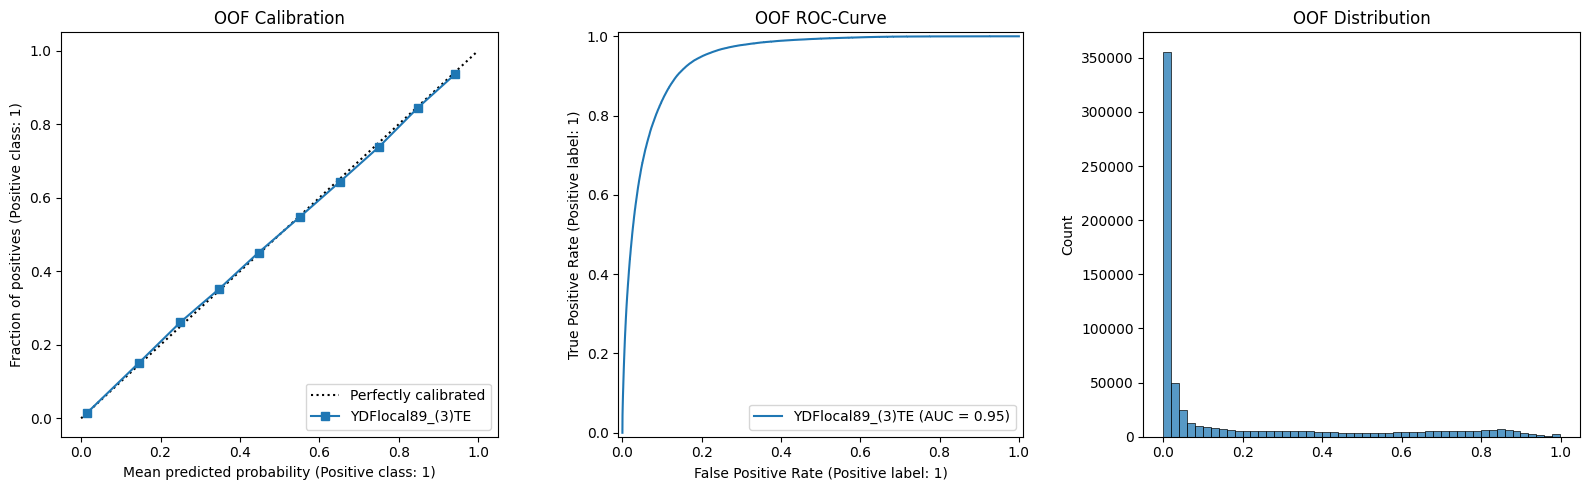

In [16]:
## -- Plot oof distributions --
_, axs = plt.subplots(1, 3, figsize=(16, 5)) 

CalibrationDisplay.from_predictions(y, oof_preds, n_bins=10, name=MODEL_NAME, ax=axs[0])
axs[0].set_title(f"OOF Calibration")

RocCurveDisplay.from_predictions(y, oof_preds, name=MODEL_NAME, ax=axs[1])
axs[1].set_title(f"OOF ROC-Curve")

sns.histplot(oof_preds, ax=axs[2], bins=50)
axs[2].set_title(f"OOF Distribution")

plt.tight_layout()
plt.show()

In [17]:
# !rm -r /kaggle/working/